In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit import transpile
import math
from qiskit.quantum_info import DensityMatrix, Statevector

In [2]:
qasm_simulator = Aer.get_backend('qasm_simulator')
statevector_simulator = Aer.get_backend('statevector_simulator')

In [3]:
def run_on_simulators(circuit):
    compiled_circuit = transpile(circuit, backend=statevector_simulator)
    job = statevector_simulator.run(compiled_circuit, shots=1024)
    result = job.result()
    statevec = result.get_statevector()
    num_qubits = circuit.num_qubits
    # r = [i for i in range(num_qubits)]
    # circuit.measure(r, r)
    circuit.measure_all()
    return result, statevec or Statevector([])

## 1. Superdense Coding

Alice and Bob starts with a shared Bell pair and choose 2 bits, and for Bob to recover Alice's selected bits, he has to apply a CNOT + H operation (e.g. opposite of result and switching the result into compoutational basis from superposition state).

Imagine where $|ab⟩ + |cd⟩$. Remember, $X$ flips the bit, $Z$ flips the phase. Imagine if Alice ($a, c$) and Bob ($b, d$) starts with both $a,b = 0$ and $c,d = 1$ respectively, and Alice only flips her bits.

| Message | Gate | Rotation | Bell State | Post-CNOT Operation | Post-H Operation |
| -- | -- | -- | -- | -- | -- |  
| 00 | $I = \begin{bmatrix}1&0\\0&1\end{bmatrix}$ | - | $\|Φ+⟩ → \frac{1}{\sqrt{2}}(\|00⟩ + \|11⟩)$ | $\frac{1}{\sqrt{2}}(\|00⟩ + \|10⟩)$ | $\frac{1}{\sqrt{2}}(\|0⟩ + \|1⟩) \otimes \frac{1}{\sqrt{2}}(\|0⟩ + \|0⟩) = 00$ |
| 01 | $X = \begin{bmatrix}0&1\\1&0\end{bmatrix}$  | $$R_x(π)$$ | $\|Ψ+⟩ → \frac{1}{\sqrt{2}}(\|10⟩ + \|01⟩)$ | $\frac{1}{\sqrt{2}}(\|11⟩ + \|01⟩)$ | $\frac{1}{\sqrt{2}}(\|1⟩ + \|0⟩) \otimes \frac{1}{\sqrt{2}}(\|1⟩ + \|1⟩) = 01$ |
| 10 | $Z = \begin{bmatrix}1&0\\0&-1\end{bmatrix}$ | $$R_z(π)$$ | $\|Φ-⟩ → \frac{1}{\sqrt{2}}(\|00⟩ - \|11⟩)$ | $\frac{1}{\sqrt{2}}(\|00⟩ - \|10⟩)$ | $\frac{1}{\sqrt{2}}(\|0⟩ - \|1⟩) \otimes \frac{1}{\sqrt{2}}(\|0⟩ - \|0⟩) = 10$ |
| 11 | $X \cdot Z = \begin{bmatrix}0&-1\\1&0\end{bmatrix}$ | $e^{-i\frac{\pi}{2}} R_y(\pi)$ | $\|Ψ-⟩ → \frac{1}{\sqrt{2}}(\|10⟩ - \|01)$ | $\frac{1}{\sqrt{2}}(\|11⟩ - \|01⟩)$ | $\frac{1}{\sqrt{2}}(\|1⟩ - \|0⟩) \otimes \frac{1}{\sqrt{2}}(\|1⟩ - \|1⟩) = 11$ |

##### Steps

1. **T0**: Apply a Hadamard $H$ Gate to set to superposition and then $CNOT$ to create entanglement from Alice's q0 to Bob's q1.
2. **T1**: Apply computations for the desired outcome on Bob's q1.
3. **T2**: Apply $CNOT$ and then $H$ Gate (to end the superposition state) to receive the message result.


In [4]:
class SuperDense:

    def __init__(self):
        # Sharing of the Bell pair (H + CNOT)
        self.qc = QuantumCircuit(2, 2)
        self.qc.h(0)
        self.qc.cx(0, 1)
        self.qc.barrier(label="T0")
    
    def encode(self, message_bits):
        # Identity means nothing
        if message_bits == "00":
            pass
        # Pauli X Gate application
        elif message_bits == "10":
            self.qc.x(0)
        # Pauli Z Gate application
        elif message_bits == "01":
            self.qc.z(0)
        # Pauli X then Z Gate application
        elif message_bits == "11":
            self.qc.x(0)
            self.qc.z(0)

        self.qc.barrier(label="T1")

    def decode(self):
        self.qc.cx(0, 1)
        self.qc.h(0)
        self.qc.barrier(label="T2")
    
    def measure(self):
        # Each call collapses the state and mutates the circuit, so create a copy to not mutate the original circuit
        measured = self.qc.copy()
        measured.measure([0,1], [0,1])
        result, _ = run_on_simulators(measured)
        counts = result.get_counts()
        decoded = max(counts, key=counts.get)
        return decoded

Alice sends `00` message to Bob:

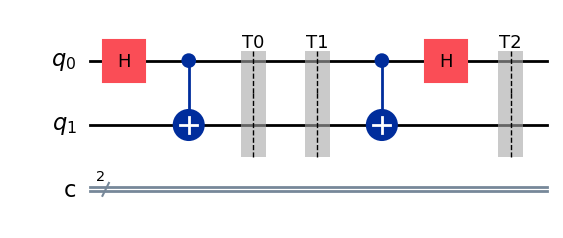

In [5]:
sd = SuperDense()
sd.encode('00')
sd.decode()
sd.qc.draw("mpl")

In [6]:
print('Decoded:', sd.measure())

Decoded: 00


Alice sends `10` message to Bob:

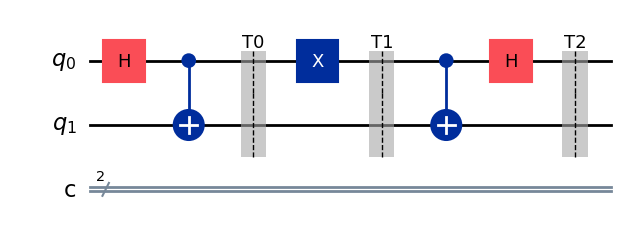

In [7]:
sd = SuperDense()
sd.encode('10')
sd.decode()
sd.qc.draw("mpl")

In [8]:
print('Decoded:', sd.measure())

Decoded: 10


Alice sends `01` message to Bob:

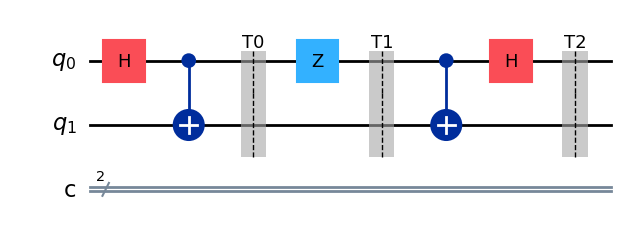

In [9]:
sd = SuperDense()
sd.encode('01')
sd.decode()
sd.qc.draw("mpl")

In [10]:
print('Decoded:', sd.measure())

Decoded: 01


Alice sends `11` message to Bob:

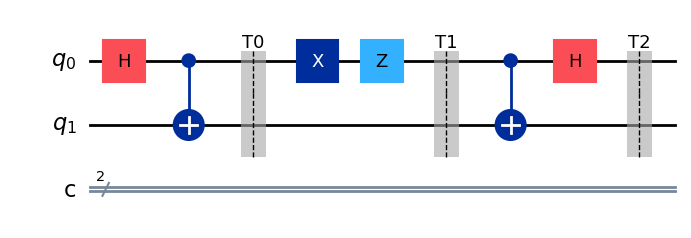

In [11]:
sd = SuperDense()
sd.encode('11')
sd.decode()
sd.qc.draw("mpl")

In [12]:
print('Decoded:', sd.measure())

Decoded: 11
